### Student Performance Indicador

### Life cycle of Machine Learning Project

 1. **Entendimento da Declaração do Problema** (Understanding the Problem Statement)
2. **Coleta de Dados** (Data Collection)
3. **Verificações de Dados a Realizar** (Data Checks to perform)
4. **Análise Exploratória de Dados** (Exploratory data analysis)
5. **Pré-processamento de Dados** (Data Pre-Processing)
6. **Treinamento do Modelo** (Model Training)
7. **Escolha do Melhor Modelo** (Choose best model)

### 1) Problema de negócio

- Este projeto visa compreender como a performance dos estudantes (notas) são afetadas por fatores como a idade, gênero, entre outros.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('../notebook/data/stud.csv') 

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape    

(1000, 8)

### 2.1 Informações do Conjunto de Dados

*   **gender** (Gênero): Sexo dos estudantes -> (Masculino/Feminino)
*   **race/ethnicity** (Raça/Etnia): Etnia dos estudantes -> (Grupo A, B, C, D, E)
*   **parental level of education** (Nível de Escolaridade dos Pais): Educação final dos pais -> (Bacharelado, alguma faculdade, mestrado, tecnólogo, ensino médio)
*   **lunch** (Almoço): Tipo de almoço antes do teste -> (Padrão ou gratuito/reduzido)
*   **test preparation course** (Curso Preparatório): Status de conclusão do curso preparatório -> (Completo ou não completo)
*   **math score** (Nota em Matemática): Pontuação obtida no teste de matemática
*   **reading score** (Nota em Leitura): Pontuação obtida no teste de leitura
*   **writing score** (Nota em Escrita): Pontuação obtida no teste de escrita

### 3 Verificações de Dados a Realizar

*   **Verificar valores ausentes** (Check Missing values)
*   **Verificar duplicatas** (Check Duplicates)
*   **Verificar o tipo de dados** (Check data type)
*   **Verificar o número de valores únicos de cada coluna** (Check the number of unique values of each column)
*   **Verificar estatísticas do conjunto de dados** (Check statistics of data set)
*   **Verificar várias categorias presentes nas diferentes colunas categóricas** (Check various categories present in the different categorical column)

### 3.1 Verificar valores ausentes

#### Não há valores nulos em nosso dataset.

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

### 3.2 Checar valores duplicados

#### Não há valores duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

#### 3.3 Checar os tipos de dados do dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checando a quantidade de valores únicos em cada coluna

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### 3.5 Checando a qualidade dos dados com estatísticas descritivas

Através do cálculo do Intervalo Interquartil (IQR), identificamos outliers no limite inferior. Observamos alunos com notas muito baixas (inclusive zero), o que representa um comportamento estatisticamente atípico quando comparado à distribuição principal das notas da turma.

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


O perfil típico ou mais frequente encontrado no dataset possui essas características (Mulher, Grupo C, Pais com faculdade incompleta...

Mas estatisticamente, o Grupo C e Escolaridade são apenas as categorias predominantes ou modais, e não a "maioria.

In [10]:
df.describe(include="object")

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### 3.6 Explorando os dados

In [11]:
print("Categorias em 'gender' variavél: ", end=" ") 
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end= " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test_preparation_course'].unique())

Categorias em 'gender' variavél:  ['female' 'male']
Categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


#### Vamos definir colunas numericas e categoricas

In [12]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


# 3.7 - Adicionando colunas para a análise: "total_score" e "average"

In [13]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Vamos análisar a quantidade de alunos que obtiveram 100% da nota em Matemática, redação e leitura:

De mil alunos, 7 tiveram nota 10 em matemática, 17 alunos em leitura e 14 alunos em redação.

In [14]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f"Number of students with full marks in Maths: {math_full}")
print(f"Number of students with full marks in Reading: {reading_full}")
print(f"Number of students with full marks in Writing: {writing_full}")

Number of students with full marks in Maths: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


### Agora vamos verificar a quantidade de alunos que obtiveram notas baixas:

De 1000 alunos, pouquíssimos obtiveram notas baixas menores que 20 nas três matérias analisadas.

In [15]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f"Number of students with reading score less than or equal to 20: {reading_less_20}")
print(f"Number of students with writing score less than or equal to 20: {writing_less_20}")
print(f"Number of students with math score less than or equal to 20: {math_less_20}")

Number of students with reading score less than or equal to 20: 1
Number of students with writing score less than or equal to 20: 3
Number of students with math score less than or equal to 20: 4


### 4.1 Visualização de dados

#### Vamos visualizar a distribuição da média de notas totais e fazer algumas conclusões.

### 4. Análise da Distribuição de Médias (Qualitativa)

**1. Distribuição Geral das Notas:**
Ao analisarmos o histograma de distribuição geral, podemos afirmar que a grande maioria dos alunos obteve uma média geral de notas concentrada no intervalo entre **60 e 80 pontos**. A curva apresenta um comportamento de distribuição normal, onde os extremos (notas muito baixas ou muito altas) são menos frequentes.

**2. Análise Comparativa por Gênero:**
No segundo gráfico, ao utilizarmos o `hue` para segregar os dados por sexo, observamos uma distinção clara de desempenho:
*   A curva de distribuição das notas do **sexo feminino** está ligeiramente deslocada para a direita em comparação à do sexo masculino.
*   Isso indica que, neste conjunto de dados, as alunas tendem a ter um desempenho geral superior (médias mais altas nas 3 matérias combinadas) se comparadas aos alunos do sexo masculino.

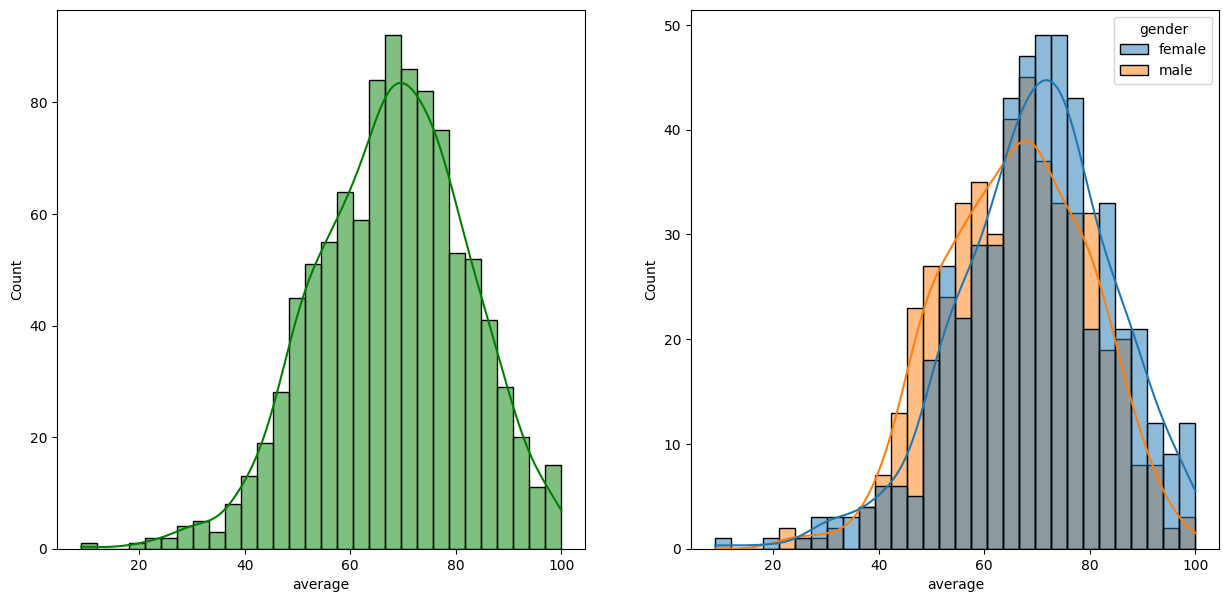

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', bins=30, kde=True, hue='gender') 
plt.show()

Embora a correlação visual seja nítida, vale lembrar que, o tipo de lanche geralmente atua como uma variável proxy para o nível socioeconômico do aluno. Portanto, os gráficos mostram que alunos em condições financeiras mais estáveis (que pagam o lanche padrão) tendem a ter acesso a mais recursos ou suporte que resultam em notas maiores.

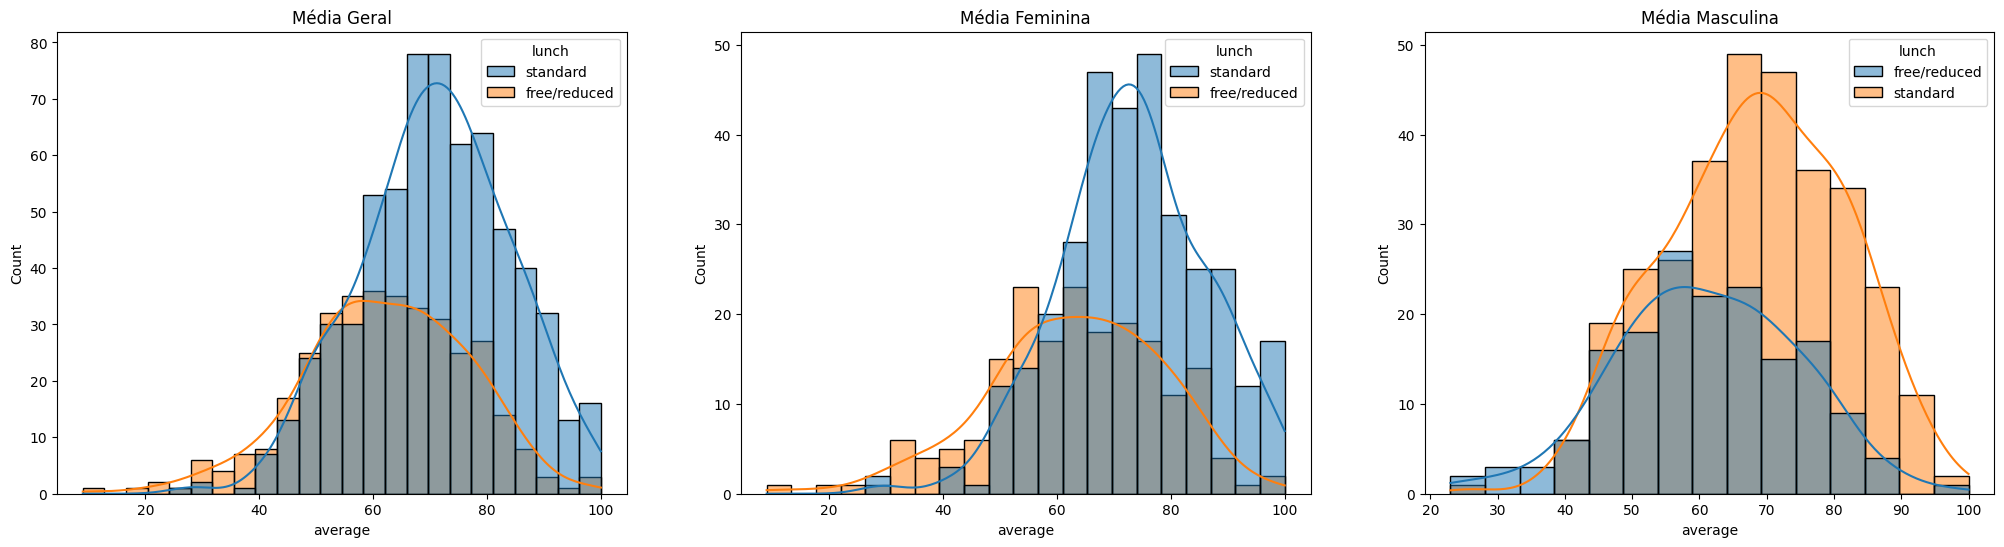

In [19]:
plt.subplots(1,3,figsize=(25,6))

plt.subplot(131)
sns.histplot(data=df,x='average', kde=True, hue='lunch')
plt.title('Média Geral')


plt.subplot(132)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='lunch')
plt.title('Média Feminina')


plt.subplot(133)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='lunch')
plt.title('Média Masculina')


plt.show()



### Por que existe um padrão (mesmo que sutil)?

* **Deslocamento dos Picos (Moda):** No gráfico de "Média Geral", observe que o pico das curvas de alunos com pais com **Master's Degree** (verde) e **Bachelor's Degree** (azul) está situado mais à direita (perto de **70-80**). Já o pico para **High School** (roxo) e **Some High School** (marrom) está mais à esquerda, em torno de **60**.
* **Densidade nas Notas Altas:** Note que na faixa de excelência (notas 90 a 100), a proporção de alunos cujos pais têm ensino superior (Master's e Bachelor's) é visualmente maior do que a daqueles cujos pais pararam no ensino médio.
* **Fator "Ruído" vs. Tendência:** A impressão de "falta de padrão" vem do fato de que a **variância** é alta em todos os grupos. Isso significa que um aluno de qualquer origem pode tirar nota 100 ou nota 20, mas a *probabilidade* de tirar uma nota alta aumenta estatisticamente com a escolaridade dos pais neste dataset.


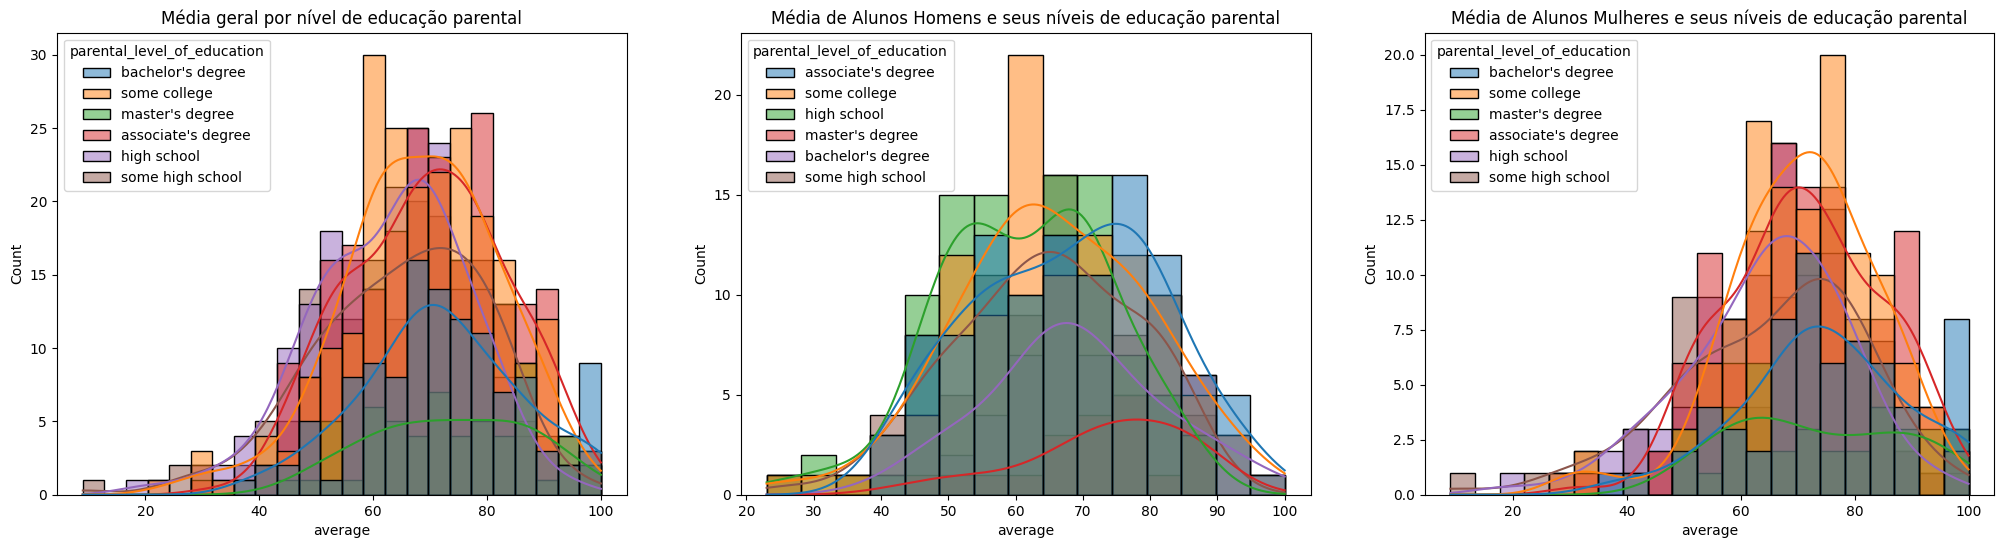

In [21]:
plt.subplots(1,3, figsize=(25,6))

plt.subplot(131)
ax = sns.histplot(data= df, x='average', kde=True, hue='parental_level_of_education')
plt.title('Média geral por nível de educação parental')

plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental_level_of_education')
plt.title('Média de Alunos Homens e seus níveis de educação parental')

plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education')
plt.title('Média de Alunos Mulheres e seus níveis de educação parental')

plt.show()



### 1. Sobre o Grupo C (Frequência vs. Performance)

* **O que isso significa:** O Grupo C é a maior população dessa amostra. Por ter mais alunos, o "volume" de notas (a área sob a curva) é maior.
* **Ponto de atenção:** Se olharmos para a **performance (as curvas KDE)**, note que o pico (a moda) do Grupo C geralmente está entre 60 e 70. Já grupos como o **D (vermelho)** e o **E (roxo)** têm suas curvas deslocadas mais para a direita (em direção ao 80-100). Portanto, o Grupo C se destaca em **quantidade**, mas os Grupos D e E costumam ter **médias superiores**.

### 2. Sobre o Grupo D (Destaque Feminino)

* Enquanto o pico das alunas do Grupo C está em torno de **70**, o das alunas do Grupo D se aproxima dos **75-80**.
* Além disso, a "cauda" da distribuição do Grupo D no gráfico feminino é bem mais densa na zona de excelência (notas acima de 90) do que a do Grupo C.

### 3. Síntese da Comparação

* **Grupo C:** É o grupo "dominante" no gráfico por ser o mais numeroso, o que dá a impressão de que eles estão em todo lugar.
* **Grupo D (e E):** São os grupos que, proporcionalmente, entregam as melhores notas médias. O Grupo D masculino, por exemplo, tem um pico de densidade próximo a **70-75**, enquanto o C masculino cai para a faixa dos **60-65**.


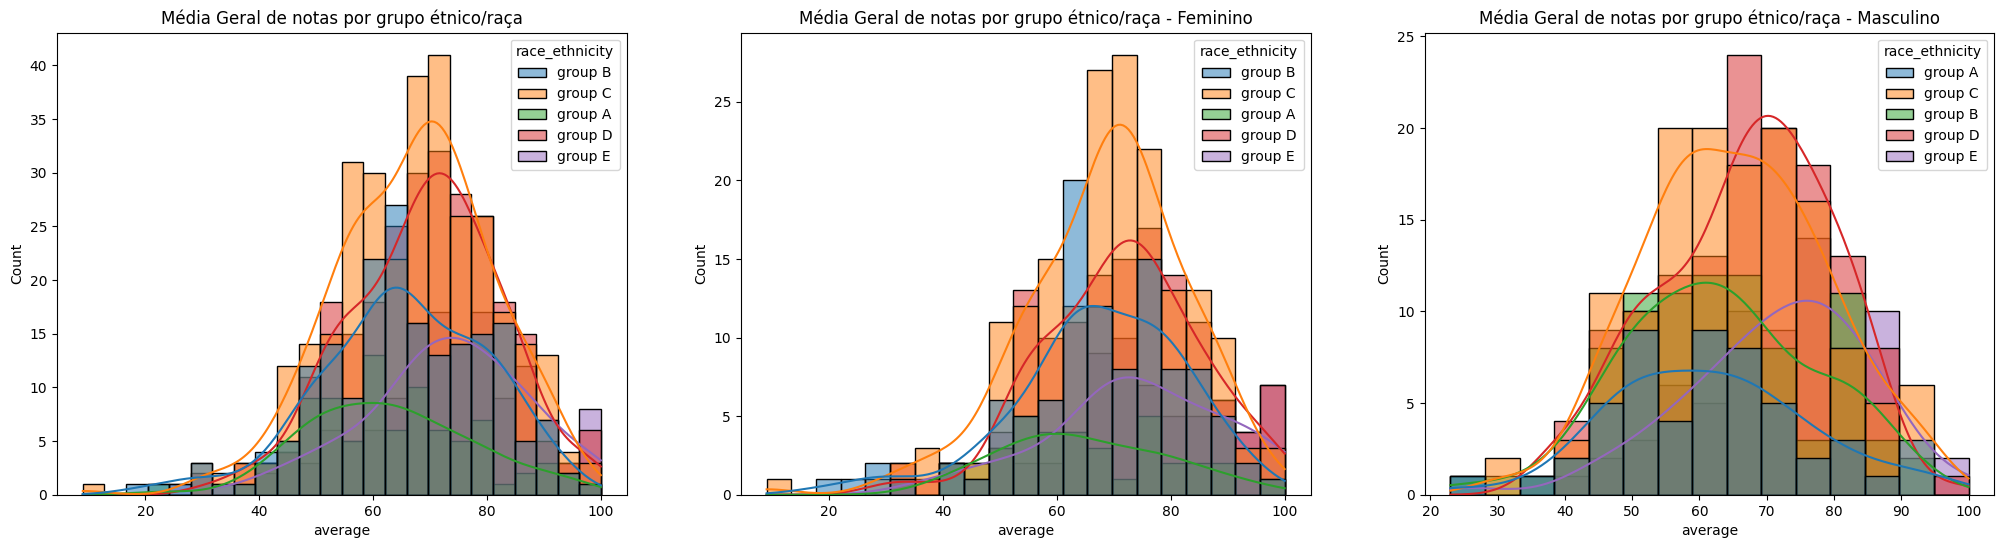

In [23]:
plt.subplots(1,3, figsize=(25, 6))


plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.title('Média Geral de notas por grupo étnico/raça')

plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race_ethnicity')
plt.title('Média Geral de notas por grupo étnico/raça - Feminino')

plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race_ethnicity')
plt.title('Média Geral de notas por grupo étnico/raça - Masculino')
plt.show()
